In [37]:
## 1. Data Cleaning & Preparation

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option('display.max_columns', None)


In [9]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

sentiment.head()
trades.head()


Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
print("Sentiment missing values:\n", sentiment.isnull().sum())
print("\nTrades missing values:\n", trades.isnull().sum())


Sentiment missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [11]:
print("Duplicate trades:", trades.duplicated().sum())


Duplicate trades: 0


In [13]:
# convert date
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# extract only date
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['Timestamp IST'].dt.date

In [14]:
df = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

df.rename(columns={'classification':'sentiment'}, inplace=True)

print(df.shape)
df.head()


(211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [36]:
# 2. Feature Engineering & Metrics


In [16]:
df['win'] = df['Closed PnL'] > 0
daily_pnl = df.groupby(['Account','date','sentiment'])['Closed PnL'].sum().reset_index()
daily_pnl.head()



,Account,date,sentiment,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1


In [17]:
winrate = df.groupby('sentiment')['win'].mean()*100
print(winrate)


sentiment
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


In [18]:
avg_size = df.groupby('sentiment')['Size USD'].mean()
print(avg_size)


sentiment
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [19]:
trades_day = df.groupby(['date','sentiment']).size().reset_index(name='num_trades')
trades_day.head()


,date,sentiment,num_trades
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


In [35]:
# 3. Analysis: Trader Behavior vs Market Sentiment


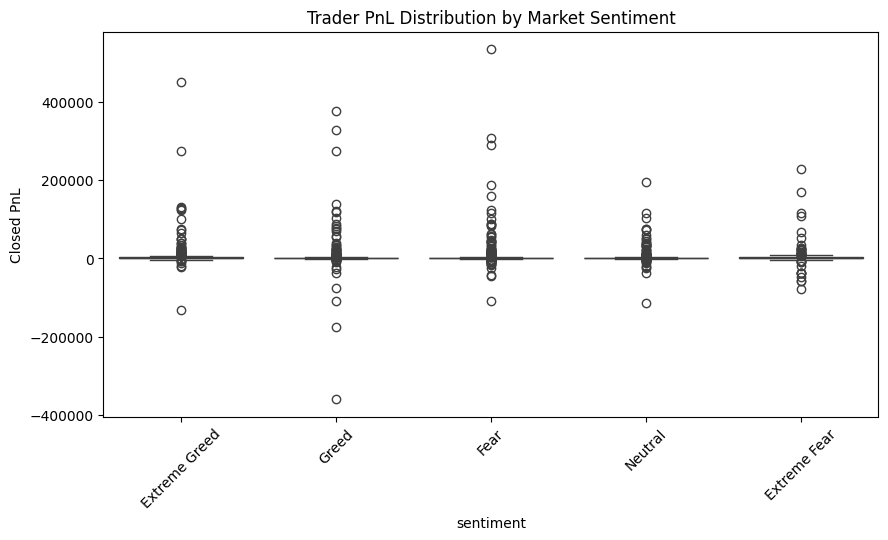

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=daily_pnl, x='sentiment', y='Closed PnL')
plt.xticks(rotation=45)
plt.title("Trader PnL Distribution by Market Sentiment")
plt.show()


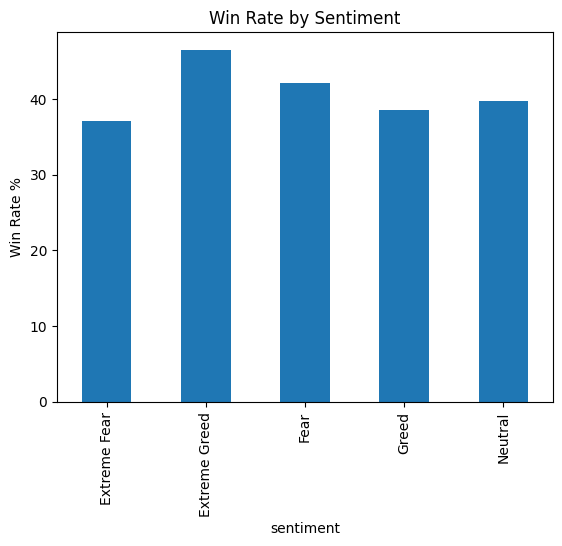

In [21]:
winrate.plot(kind='bar', title="Win Rate by Sentiment")
plt.ylabel("Win Rate %")
plt.show()


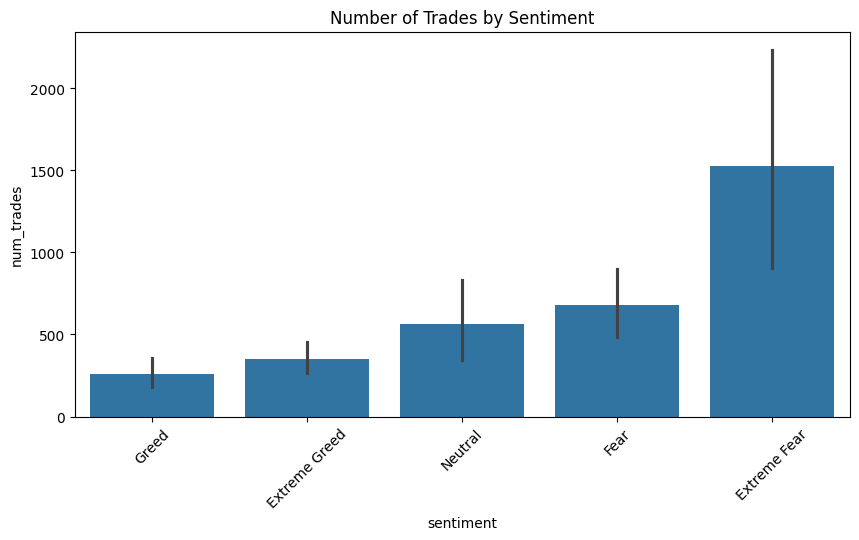

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=trades_day, x='sentiment', y='num_trades')
plt.xticks(rotation=45)
plt.title("Number of Trades by Sentiment")
plt.show()


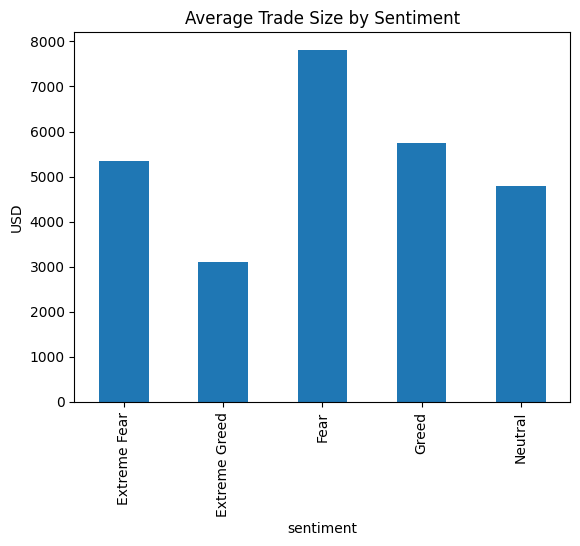

In [23]:
avg_size.plot(kind='bar', title="Average Trade Size by Sentiment")
plt.ylabel("USD")
plt.show()


In [26]:
# 4. Trader Segmentation


In [24]:
trade_count = df['Account'].value_counts()

high_traders = trade_count[trade_count>50].index

df['trader_type'] = df['Account'].apply(
    lambda x: 'High freq' if x in high_traders else 'Low freq'
)


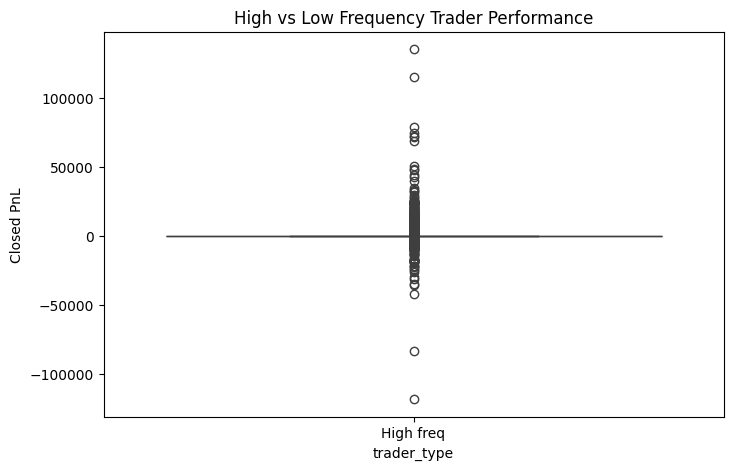

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='trader_type', y='Closed PnL')
plt.title("High vs Low Frequency Trader Performance")
plt.show()


In [27]:
# 6. Advanced Behavioral Analysis


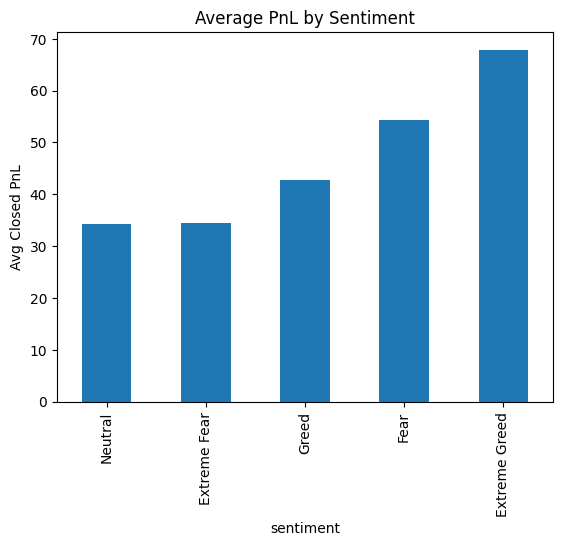

sentiment
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64


In [28]:
fear_greed_pnl = df.groupby('sentiment')['Closed PnL'].mean().sort_values()

fear_greed_pnl.plot(kind='bar', title="Average PnL by Sentiment")
plt.ylabel("Avg Closed PnL")
plt.show()

print(fear_greed_pnl)


In [30]:
# 7. Predicting Trader Profitability (using ML Random Forest)


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [33]:
model_df = df.copy()

model_df['profit'] = model_df['Closed PnL'] > 0
model_df['sentiment'] = model_df['sentiment'].astype('category').cat.codes

features = ['Size USD','sentiment']
model_df = model_df.dropna(subset=features)

X = model_df[features]
y = model_df['profit']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


Accuracy: 0.6102734051367026
              precision    recall  f1-score   support

       False       0.67      0.68      0.67     24802
        True       0.53      0.52      0.52     17443

    accuracy                           0.61     42245
   macro avg       0.60      0.60      0.60     42245
weighted avg       0.61      0.61      0.61     42245

